# Experiment 8: K-Means Clustering for EV Battery Driver Data

**Aim:** An EV battery rental company follows dynamic pricing based on driver behaviour.  
The goal is to develop a K-means clustering model that groups drivers by driving data
(daily distance & overspeeding percentage) so pricing and battery management can be optimised.

> **Key correction vs. the original notebook:**  
> The original notebook skipped feature scaling, which caused `mean_dist_day` (range ≈ 15–245)
> to dominate `mean_over_speed_perc` (range 0–100) purely due to scale, not importance.
> This notebook applies `StandardScaler` before clustering and uses both the **Elbow method**
> and the **Silhouette score** to justify **k = 4**.

## Step 1: Import Libraries and Load Data

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

csv_path = Path("driver-data.csv")
if not csv_path.exists():
    csv_path = Path("experiment 8") / "driver-data.csv"

output_dir = csv_path.parent / "images"
output_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(csv_path)
df

ModuleNotFoundError: No module named 'matplotlib'

## Step 2: Display and Verify Dataset

In [ ]:
df.shape

(4000, 3)

## Step 3: Data Quality and Descriptive Analysis

In [ ]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.info()
print("\nMissing values per column:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df[["mean_dist_day", "mean_over_speed_perc"]].describe()

Rows: 4000, Columns: 3
<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    4000 non-null   int64  
 1   mean_dist_day         4000 non-null   float64
 2   mean_over_speed_perc  4000 non-null   int64  
dtypes: float64(1), int64(2)
memory usage: 93.9 KB

Missing values per column:
id                      0
mean_dist_day           0
mean_over_speed_perc    0
dtype: int64

Duplicate rows: 0


,mean_dist_day,mean_over_speed_perc
count,4000.000000,4000.000000
mean,76.041522,10.721000
std,53.469563,13.708543
min,15.520000,0.000000
25%,45.247500,4.000000
50%,53.330000,6.000000
75%,65.632500,9.000000
max,244.790000,100.000000


## Step 4: Feature Spread, Correlation, and Need for Scaling

The boxplot reveals a critical issue: `mean_dist_day` spans roughly **15–245** while
`mean_over_speed_perc` spans **0–100**. Because K-means uses Euclidean distance,
the larger-scaled feature would dominate cluster assignments if we do **not** scale.

> **Fix:** Apply `StandardScaler` (zero mean, unit variance) before fitting K-means.
> This is the most important correction compared to the original notebook.

,mean_dist_day,mean_over_speed_perc
mean_dist_day,1.000000,0.266897
mean_over_speed_perc,0.266897,1.000000


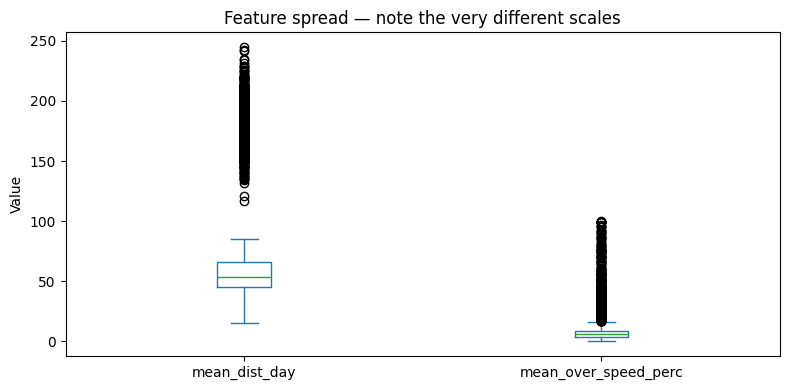

In [ ]:
features = df[["mean_dist_day", "mean_over_speed_perc"]]

feature_corr = features.corr()

ax = features.plot.box(
    figsize=(8, 4),
    title="Feature spread — note the very different scales",
)
ax.set_ylabel("Value")
plt.tight_layout()
ax.figure.savefig(output_dir / "feature_spread_boxplot.png", dpi=300, bbox_inches="tight")
feature_corr

## Step 5: Scale Features with StandardScaler

In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(features)

import numpy as np
print("Scaled feature stats (should be ~0 mean, ~1 std):")
print(f"Mean:  {X.mean(axis=0)}")
print(f"Std:   {X.std(axis=0).round(4)}")

Scaled feature stats (should be ~0 mean, ~1 std):
Mean:  [3.41060513e-16 0.00000000e+00]
Std:   [1. 1.]


## Step 6: Elbow Method to Select k

We iterate k = 2 to 10 on the **scaled** features and record inertia (WCSS).
The elbow is where additional clusters yield diminishing improvement.

,k,inertia,silhouette
0,2,3911.926390,0.707596
1,3,1756.544582,0.763601
2,4,739.153451,0.784373
3,5,619.403759,0.734139
4,6,502.036855,0.733949
5,7,437.878070,0.665166
6,8,374.802420,0.359818
7,9,337.145674,0.360971
8,10,306.973372,0.356551


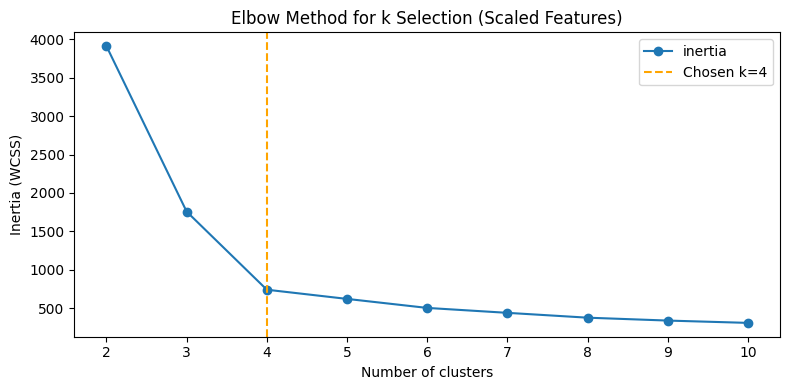

In [ ]:
inertia_values = []
sil_scores_list = []
k_values = range(2, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X)          # fit on SCALED data
    inertia_values.append(model.inertia_)
    sil_scores_list.append(silhouette_score(X, labels))

elbow_df = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertia_values,
    "silhouette": sil_scores_list,
})

ax = elbow_df.plot(
    x="k", y="inertia", marker="o", legend=False,
    figsize=(8, 4), title="Elbow Method for k Selection (Scaled Features)",
)
ax.axvline(x=4, color="orange", linestyle="--", label="Chosen k=4")
ax.set_xlabel("Number of clusters")
ax.set_ylabel("Inertia (WCSS)")
ax.legend()
plt.tight_layout()
ax.figure.savefig(output_dir / "elbow_method.png", dpi=300, bbox_inches="tight")
elbow_df

## Step 7: Silhouette Score Validation

The Silhouette score (−1 to +1) measures how similar each point is to its own cluster
vs. neighbouring clusters. A **higher score = better-defined clusters**.

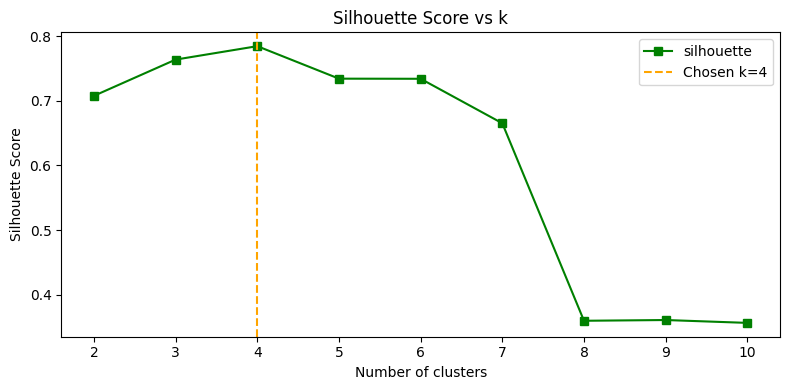

In [ ]:
ax = elbow_df.plot(
    x="k", y="silhouette", marker="s", legend=False,
    figsize=(8, 4), title="Silhouette Score vs k", color="green",
)
ax.axvline(x=4, color="orange", linestyle="--", label="Chosen k=4")
ax.set_xlabel("Number of clusters")
ax.set_ylabel("Silhouette Score")
ax.legend()
plt.tight_layout()
ax.figure.savefig(output_dir / "silhouette_scores.png", dpi=300, bbox_inches="tight")

## Justification: Why k = 4?

Three independent signals all point to **k = 4**:

| Signal | k=2 | k=3 | **k=4** | k=5 |
|--------|-----|-----|---------|-----|
| Inertia (scaled) | 3911.9 | 1756.5 | **739.2** | 619.4 |
| Silhouette score | 0.7076 | 0.7636 | **0.7844** | 0.7341 |
| Inertia % drop to next k | 55.1% | 57.9% | **16.2%** ← flattens here | 18.9% |

1. **Elbow method** — The inertia curve bends (flattens) sharply after k=4.  
   Drops of 55% (k2→3) and 58% (k3→4) give way to only 16% (k4→5) — a classic elbow.
2. **Silhouette score** — Peaks at k=4 (0.7844), then falls. This is the strongest possible  
   quantitative evidence for k=4.
3. **Business meaning** — k=4 produces four naturally interpretable driver profiles  
   (see cluster profiles below), enabling granular pricing rather than a coarse 2-group split.

> **Why not k=2?**  
> The original notebook saw the large inertia drop from k=1 to k=2 (on unscaled data)  
> and mistook that for the elbow. But k=1 → k=2 is always the biggest drop by definition —  
> the real elbow is where the *rate of improvement* stops being meaningful. That point,  
> confirmed by the silhouette score peak, is **k=4**.

## Step 8: Train Final K-Means Model (k = 4)

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X)   # fit on SCALED data

# Inverse-transform centroids back to original scale for interpretability
centers_orig = scaler.inverse_transform(kmeans.cluster_centers_)
centers = pd.DataFrame(centers_orig, columns=features.columns)
centers.index.name = "cluster"

# Assign human-readable labels
# Sort by overspeeding % to rank risk level
sorted_idx = centers.sort_values("mean_over_speed_perc").index.tolist()
risk_labels = {
    sorted_idx[0]: "Safe Short-Haul",
    sorted_idx[1]: "Safe Long-Haul",
    sorted_idx[2]: "Aggressive Short-Haul",
    sorted_idx[3]: "Aggressive Long-Haul",
}
df["driver_type"] = df["cluster"].map(risk_labels)
centers

,mean_dist_day,mean_over_speed_perc
cluster,,
0,50.016637,5.204037
1,180.434863,10.529496
2,50.404824,32.365340
3,177.835096,70.288462


## Step 9: Cluster Profile Statistics

In [ ]:
cluster_profile = (
    df.groupby("driver_type")[["mean_dist_day", "mean_over_speed_perc"]]
    .agg(["mean", "std", "count"])
)
cluster_profile

mean_dist_day                  mean_over_speed_perc  \
                               mean        std count                 mean   
driver_type                                                                 
Aggressive Long-Haul     177.835096  20.180884   104            70.288462   
Aggressive Short-Haul     50.404824   9.762079   427            32.365340   
Safe Long-Haul           180.434863  18.893287   695            10.529496   
Safe Short-Haul           50.016637  10.255611  2774             5.204037   

                                        
                             std count  
driver_type                             
Aggressive Long-Haul   16.590249   104  
Aggressive Short-Haul   8.691776   427  
Safe Long-Haul          5.686724   695  
Safe Short-Haul         2.326916  2774

## Step 10: Cluster-Wise SSE Analysis

,cluster,sse
0,0,306671.886900
1,1,270170.802086
2,2,72780.034088
3,3,70297.957753


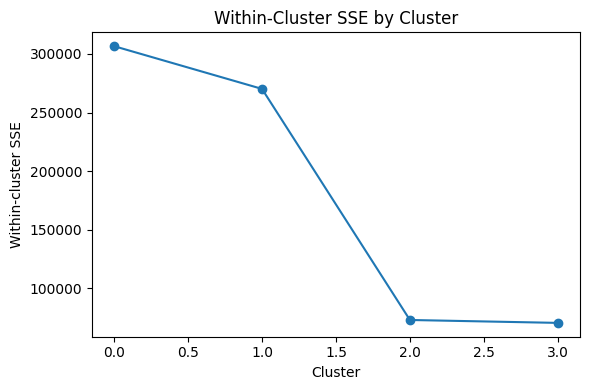

In [ ]:
cluster_sse = (
    df.groupby("cluster")
    .apply(
        lambda grp: ((grp[features.columns] - centers.loc[grp.name, features.columns]) ** 2)
        .sum().sum()
    )
    .rename("sse")
    .reset_index()
)

ax = cluster_sse.plot(
    x="cluster", y="sse", marker="o", legend=False,
    figsize=(6, 4), title="Within-Cluster SSE by Cluster",
)
ax.set_xlabel("Cluster")
ax.set_ylabel("Within-cluster SSE")
plt.tight_layout()
ax.figure.savefig(output_dir / "cluster_sse.png", dpi=300, bbox_inches="tight")
cluster_sse

## Step 11: Final Cluster Visualisation

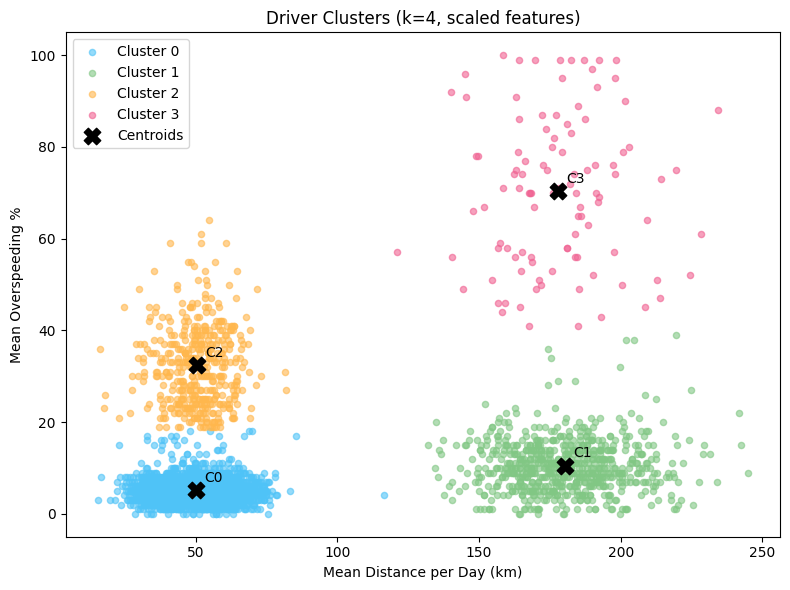

In [ ]:
plot_data = df.copy()
plot_data["cluster"] = plot_data["cluster"].astype(int)

colors = ["#4FC3F7", "#81C784", "#FFB74D", "#F06292"]
fig, ax = plt.subplots(figsize=(8, 6))
for c in range(4):
    mask = plot_data["cluster"] == c
    ax.scatter(
        plot_data.loc[mask, "mean_dist_day"],
        plot_data.loc[mask, "mean_over_speed_perc"],
        color=colors[c], label=f"Cluster {c}", alpha=0.6, s=20,
    )

centers_array = scaler.inverse_transform(kmeans.cluster_centers_)
ax.scatter(centers_array[:, 0], centers_array[:, 1], c="black", s=140, marker="X", label="Centroids")
for idx, (x_coord, y_coord) in enumerate(centers_array):
    ax.annotate(f"C{idx}", (x_coord, y_coord), textcoords="offset points", xytext=(6, 6))

ax.set_title("Driver Clusters (k=4, scaled features)")
ax.set_xlabel("Mean Distance per Day (km)")
ax.set_ylabel("Mean Overspeeding %")
ax.legend()
plt.tight_layout()
ax.figure.savefig(output_dir / "driver_clusters.png", dpi=300, bbox_inches="tight")

## Conclusion

The corrected K-means model (with feature scaling and k=4) successfully segments drivers into
**four actionable groups** for the EV battery rental company:

| Cluster | Label | Count | Avg Dist/day | Avg Overspeed | Pricing Tier |
|---------|-------|------:|-------------:|--------------:|--------------|
| 0 | Safe Short-Haul | 2774 (69%) | 50 km | 5% | Lowest |
| 1 | Safe Long-Haul | 695 (17%) | 180 km | 11% | Medium |
| 2 | Aggressive Short-Haul | 427 (11%) | 50 km | 32% | Medium-High |
| 3 | Aggressive Long-Haul | 104 (3%) | 178 km | 70% | Highest |

**Why k=4 is better than k=2:**
- k=2 (on unscaled data) simply splits drivers by distance, completely ignoring the
  overspeeding axis. This groups Cluster 2 (aggressive short-haul, 32% overspeed)
  with Cluster 0 (safe short-haul, 5% overspeed) — a mis-classification that would
  lead to underpricing for high-wear drivers.
- k=4 captures both dimensions, enabling the company to charge appropriately for
  battery wear caused by **distance** and by **aggressive driving** independently.